# Predictive Modeling

This notebook focuses on building machine learning models to predict hotel booking cancellations.

The objective of predictive modeling is to:
- identify factors influencing booking cancellations
- train classification models
- evaluate model performance
- support customer retention and revenue optimization strategies

In [44]:
import pandas as pd
import numpy as np

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [47]:
df = pd.read_csv("../data/cleaned/featured_hotel_bookings.csv")

## Selecting Features and Target Variable

The target variable for prediction is `is_canceled`, which indicates whether a hotel booking was canceled or not.

Relevant features are selected to train classification models for cancellation prediction.

In [48]:
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

## Removing Data Leakage Features

The columns `reservation_status` and `reservation_status_date` were removed because they contain information directly related to booking outcomes.

Keeping these variables would cause data leakage and produce unrealistically high prediction accuracy.

In [49]:
X = X.drop(['reservation_status', 'reservation_status_date'], axis=1)

## Encoding Categorical Variables

Machine learning models require numerical input data. Categorical variables are encoded into numerical representations using Label Encoding.

In [50]:
label_encoder = LabelEncoder()

for column in X.select_dtypes(include='object').columns:
    X[column] = label_encoder.fit_transform(X[column])

In [51]:
X.head()

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_stay,total_guests,booking_season,lead_time_category
0,1,342,2015,5,27,1,0,0,2,0,...,0.0,0,2,0.0,0,0,0,2,2,0
1,1,737,2015,5,27,1,0,0,2,0,...,0.0,0,2,0.0,0,0,0,2,2,0
2,1,7,2015,5,27,1,0,1,1,0,...,0.0,0,2,75.0,0,0,1,1,2,2
3,1,13,2015,5,27,1,0,1,1,0,...,304.0,0,2,75.0,0,0,1,1,2,2
4,1,14,2015,5,27,1,0,2,2,0,...,240.0,0,2,98.0,0,1,2,2,2,2


## Splitting Training and Testing Data

The dataset is divided into training and testing sets to evaluate model performance on unseen data.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Logistic Regression Model

Logistic Regression is used as a baseline classification model to predict booking cancellations.

In [53]:
logistic_model = LogisticRegression(
    max_iter=2000,
    solver='liblinear'
)

logistic_model.fit(X_train, y_train)

y_pred_logistic = logistic_model.predict(X_test)

## Logistic Regression Model Evaluation

The Logistic Regression model is evaluated using accuracy, classification metrics, and a confusion matrix to measure its performance in predicting booking cancellations.

In [54]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.7774027459954234


In [55]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86     12733
           1       0.65      0.38      0.48      4747

    accuracy                           0.78     17480
   macro avg       0.73      0.65      0.67     17480
weighted avg       0.76      0.78      0.76     17480



### Observation

The Logistic Regression model achieved an accuracy of approximately 77%.

The model performs well in predicting non-canceled bookings, but recall for canceled bookings is comparatively lower. This indicates that the model struggles to identify all cancellation cases accurately.

These results suggest the need for a more powerful classification model to improve cancellation prediction performance.

## Confusion Matrix Visualization

A confusion matrix is used to visualize the classification performance of the Logistic Regression model by comparing actual and predicted booking cancellation outcomes.

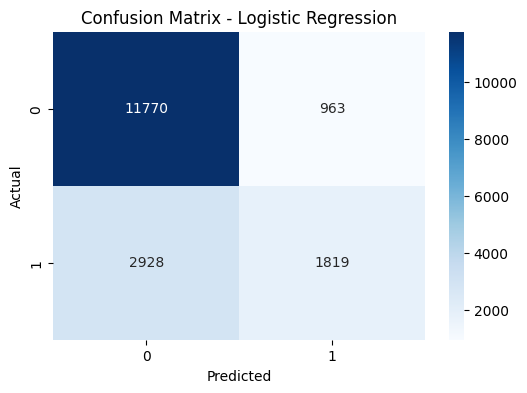

In [56]:
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Observation

The confusion matrix shows that the Logistic Regression model predicts non-canceled bookings more accurately than canceled bookings.

A relatively high number of false negatives indicates that several actual cancellations are still being classified as non-cancellations. This highlights the limitation of the baseline model and motivates the use of more advanced machine learning algorithms.

## Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve classification performance and reduce overfitting.

This model is expected to provide stronger predictive performance compared to Logistic Regression.

In [57]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

## Random Forest Model Evaluation

The Random Forest model is evaluated using accuracy, classification metrics, and confusion matrix analysis to compare its performance against Logistic Regression.

In [58]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8496567505720823


In [59]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90     12733
           1       0.77      0.64      0.70      4747

    accuracy                           0.85     17480
   macro avg       0.82      0.78      0.80     17480
weighted avg       0.84      0.85      0.84     17480



### Observation

The Random Forest model achieved significantly better performance compared to Logistic Regression.

Key improvements include:
- higher overall accuracy
- improved recall for canceled bookings
- stronger balance between precision and recall

The model is more effective at identifying booking cancellations, making it more suitable for hospitality cancellation prediction tasks.

## Confusion Matrix - Random Forest

The confusion matrix is used to visualize the classification performance of the Random Forest model and compare its prediction capability against the Logistic Regression model.

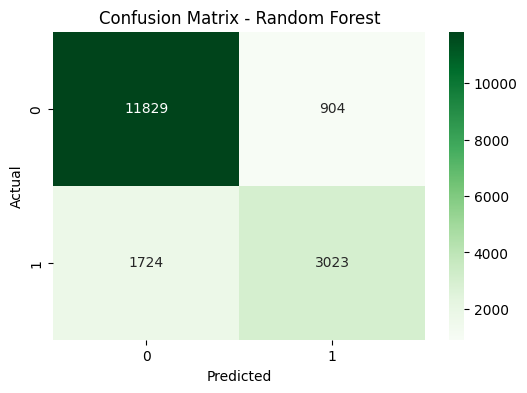

In [60]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

### Observation

The Random Forest confusion matrix demonstrates improved prediction performance compared to Logistic Regression.

The model correctly identifies a larger number of canceled bookings while also maintaining strong prediction accuracy for non-canceled bookings. This indicates that Random Forest provides a more balanced and reliable classification performance for hotel booking cancellation prediction.

## Feature Importance Analysis

Feature importance analysis helps identify which variables contribute most to predicting hotel booking cancellations in the Random Forest model.

In [61]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,lead_time,0.115992
12,country,0.100332
25,adr,0.086276
5,arrival_date_day_of_month,0.065266
22,agent,0.058607
4,arrival_date_week_number,0.058566
27,total_of_special_requests,0.057509
13,market_segment,0.048930
28,total_stay,0.038984
7,stays_in_week_nights,0.034864


### Observation

Feature importance analysis shows that `lead_time` is the most influential variable in predicting booking cancellations.

Other important predictors include:
- `country`
- `adr`
- `market_segment`
- `total_of_special_requests`

These features indicate that booking timing, customer location, pricing behavior, and booking preferences significantly influence hotel cancellation patterns.

## Model Comparison Summary

The performance of Logistic Regression and Random Forest models was compared for hotel booking cancellation prediction.

Key findings:
- Random Forest achieved higher prediction accuracy.
- Random Forest improved cancellation detection performance significantly.
- Logistic Regression served as a strong baseline model but struggled with cancellation recall.
- Random Forest provided more balanced classification performance across both classes.

Based on evaluation metrics, Random Forest was selected as the better-performing model for this project.

# Conclusion

The predictive modeling process successfully identified important factors influencing hotel booking cancellations.

Key outcomes of the project include:
- successful preprocessing and feature engineering of hotel booking data
- identification of customer behavior and seasonal booking patterns
- development of baseline and ensemble machine learning models
- improved cancellation prediction using Random Forest Classifier
- extraction of important business-driving features through feature importance analysis

The project demonstrates how data analytics and machine learning can support hospitality businesses in:
- reducing cancellation-related revenue loss
- improving customer retention strategies
- optimizing pricing decisions
- enhancing operational planning

These insights can help hotels make more informed business decisions and improve overall revenue management performance.

## Future Scope

Future improvements for this project may include:
- advanced hyperparameter tuning
- handling class imbalance using SMOTE
- deployment of predictive models
- real-time booking cancellation prediction systems
- integration with interactive business intelligence dashboards
- implementation of advanced machine learning algorithms such as XGBoost or LightGBM

These enhancements could further improve predictive performance and support more advanced hospitality analytics solutions.